# exploratory analysis

this notebook explores how online attention differs across fashion, food, and lifestyle trends. by comparing attention over time, growth, and volatility, the goal is to better understand how consumer interest changes and what these patterns may suggest about demand in the attention economy.

rather than focusing on one trend, this notebook compares multiple trends to identify broader patterns in consumer behavior.

## consumer attention over time

the first step is to examine how attention changes over time for each trend. comparing all trends on the same timeline makes it easier to identify periods of rapid growth, decline, or sustained consumer interest.

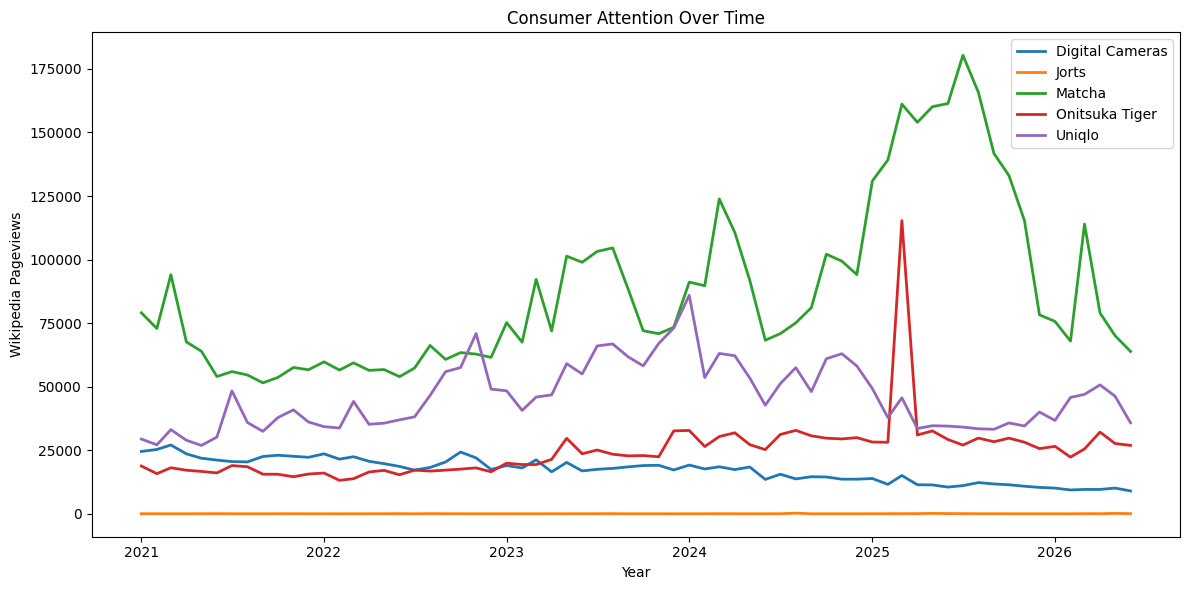

In [13]:
plt.figure(figsize=(12, 6))

for trend in pageviews_df["trend_id"].unique():
    subset = pageviews_df[pageviews_df["trend_id"] == trend]

    plt.plot(
        subset["date"],
        subset["views"],
        label=trend.replace("_", " ").title(),
        linewidth=2
    )

plt.title("Consumer Attention Over Time")
plt.xlabel("Year")
plt.ylabel("Wikipedia Pageviews")
plt.legend()

plt.tight_layout()
plt.show()

## which trends receive the most attention?

while the previous visualization shows how attention changes over time, it can be difficult to compare overall popularity. ranking the average attention for each trend provides a clearer picture of which trends consistently attract the greatest public interest.

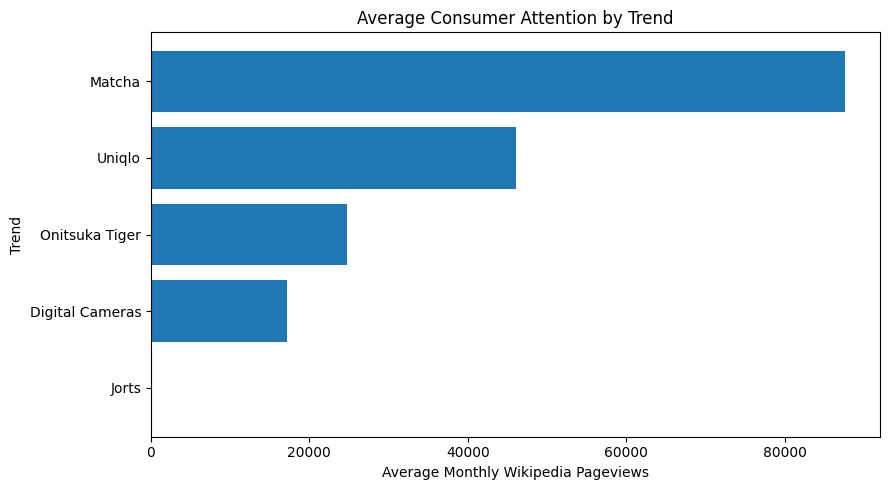

In [14]:
display_names = {
    "digital_cameras": "Digital Cameras",
    "jorts": "Jorts",
    "matcha": "Matcha",
    "onitsuka_tiger": "Onitsuka Tiger",
    "uniqlo": "Uniqlo"
}

average_attention = (
    trend_profiles
    .reset_index()
    .sort_values("average_attention", ascending=True)
)

average_attention["display_name"] = average_attention["trend_id"].map(display_names)

plt.figure(figsize=(9,5))

plt.barh(
    average_attention["display_name"],
    average_attention["average_attention"]
)

plt.title("Average Consumer Attention by Trend")
plt.xlabel("Average Monthly Wikipedia Pageviews")
plt.ylabel("Trend")

plt.tight_layout()
plt.show()

### interpretation

matcha received the highest average level of consumer attention during the study period, followed by uniqlo. in contrast, jorts attracted considerably lower average attention despite experiencing periods of growth.

this suggests that high consumer demand is not determined solely by rapid increases in popularity. some trends maintain consistently high attention over time, while others experience brief periods of heightened interest.

## which trends experienced the greatest growth?

consumer attention is not static. some trends become more popular over time, while others gradually lose attention.

comparing percentage growth highlights which trends gained momentum during the study period and which experienced declining interest.

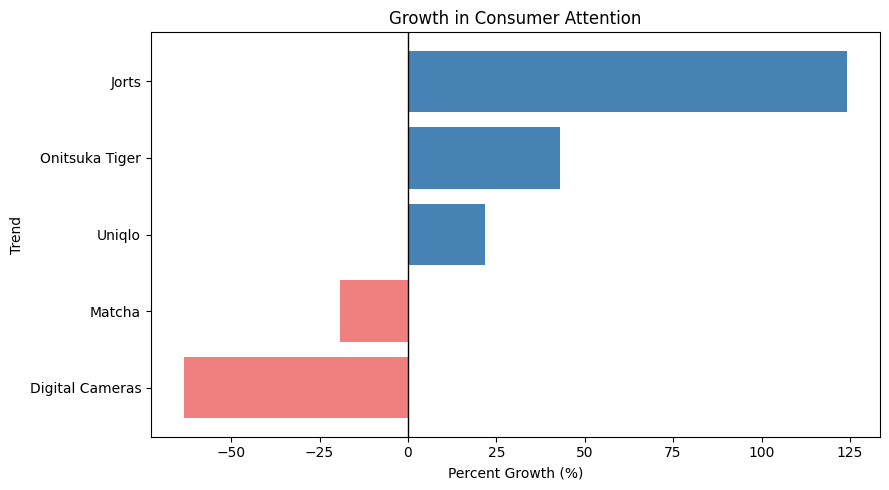

In [15]:
growth = (
    trend_profiles
    .reset_index()
    .sort_values("percent_growth")
)

growth["display_name"] = growth["trend_id"].map(display_names)

colors = [
    "steelblue" if value >= 0 else "lightcoral"
    for value in growth["percent_growth"]
]

plt.figure(figsize=(9,5))

plt.barh(
    growth["display_name"],
    growth["percent_growth"],
    color=colors
)

plt.axvline(0, color="black", linewidth=1)

plt.title("Growth in Consumer Attention")
plt.xlabel("Percent Growth (%)")
plt.ylabel("Trend")

plt.tight_layout()
plt.show()

### interpretation

jorts recorded the highest percentage growth over the study period, while digital cameras experienced the largest decline in attention.

however, percentage growth should be interpreted alongside average attention. a trend may grow rapidly from a small starting point, while another may maintain substantially higher overall attention despite slower growth.

## how do trends change relative to their own popularity?

some trends naturally receive more attention than others, making direct comparisons difficult.

to compare overall patterns rather than raw popularity, each trend is normalized to a scale between 0 and 1. this highlights how consumer interest rises and falls over time regardless of a trend's overall size.

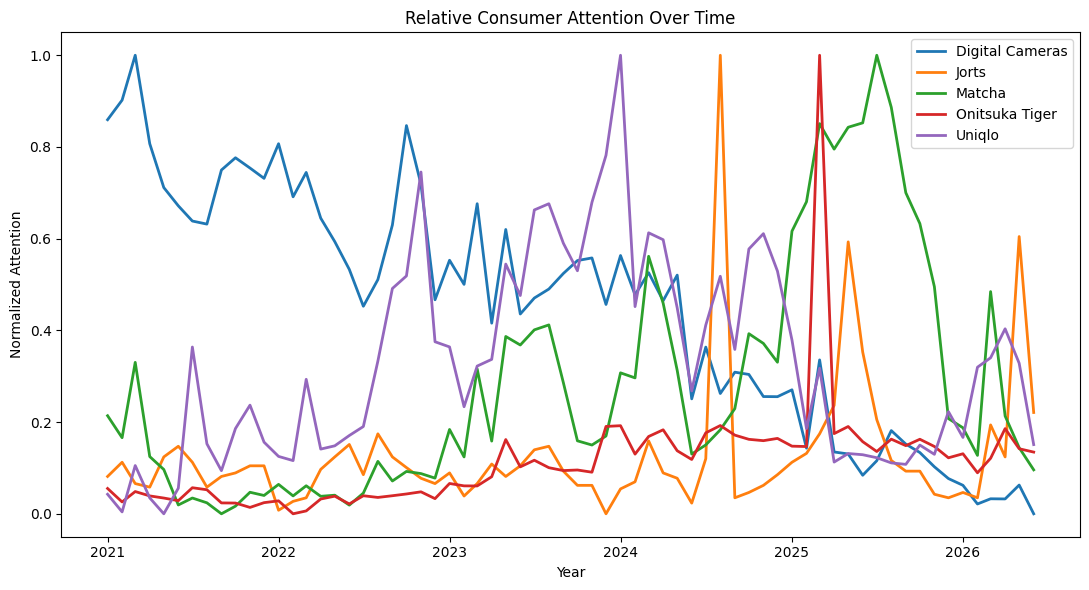

In [16]:
normalized = pageviews_df.copy()

normalized["normalized_views"] = (
    normalized.groupby("trend_id")["views"]
    .transform(lambda x: (x - x.min()) / (x.max() - x.min()))
)

normalized["display_name"] = normalized["trend_id"].map(display_names)

plt.figure(figsize=(11,6))

for trend in normalized["display_name"].unique():
    subset = normalized[normalized["display_name"] == trend]

    plt.plot(
        subset["date"],
        subset["normalized_views"],
        linewidth=2,
        label=trend
    )

plt.title("Relative Consumer Attention Over Time")
plt.xlabel("Year")
plt.ylabel("Normalized Attention")
plt.legend()

plt.tight_layout()
plt.show()

In [23]:
pageviews_df.columns

Index(['date', 'views', 'article', 'trend_id'], dtype='object')

In [24]:
pageviews_df["article"].unique()

array(['Digital camera', 'Jean shorts', 'Matcha', 'Onitsuka Tiger',
       'Uniqlo'], dtype=object)

### interpretation

normalizing the data removes differences in overall popularity and instead highlights how each trend changes over time.

this makes it easier to identify shared patterns in consumer attention, such as steady long-term growth, sudden spikes, or gradual declines, regardless of the total number of pageviews.

# key findings

this exploratory analysis revealed several differences in how online attention evolves across trends.

while some trends maintained consistently high levels of attention throughout the study period, others experienced rapid increases or gradual declines. examining both overall popularity and relative growth provides a more complete understanding of consumer demand than looking at a single metric alone.

these findings provide the foundation for the next notebook, which explores how concepts from economics can help explain why some trends sustain attention while others quickly fade.

In [17]:
summary = (
    trend_profiles
    .reset_index()[
        [
            "trend_id",
            "average_attention",
            "percent_growth"
        ]
    ]
)

summary["display_name"] = summary["trend_id"].map(display_names)

summary = summary[
    [
        "display_name",
        "average_attention",
        "percent_growth"
    ]
]

summary = summary.rename(columns={
    "display_name": "Trend",
    "average_attention": "Average Attention",
    "percent_growth": "Growth (%)"
})

summary.round(2)

,Trend,Average Attention,Growth (%)
0,Digital Cameras,17146.06,-63.33
1,Jorts,40.97,124.14
2,Matcha,87660.85,-19.24
3,Onitsuka Tiger,24721.05,43.10
4,Uniqlo,46100.55,21.74


### summary

viewing the major metrics together highlights that popularity and growth are not always the same. some trends receive consistently high attention, while others gain momentum rapidly despite beginning from a much smaller audience.

considering multiple measures together provides a clearer picture of how consumer demand develops over time.

In [18]:
summary.to_csv(
    "../data/trend_summary.csv",
    index=False
)

print("trend summary saved!")

trend summary saved!


In [21]:
print(summary.columns.tolist())

['Trend', 'Average Attention', 'Growth (%)']


In [22]:
summary

,Trend,Average Attention,Growth (%)
0,Digital Cameras,17146.06,-63.33
1,Jorts,40.97,124.14
2,Matcha,87660.85,-19.24
3,Onitsuka Tiger,24721.05,43.10
4,Uniqlo,46100.55,21.74


In [25]:
import matplotlib.pyplot as plt
import os

os.makedirs("../website/images", exist_ok=True)

trend_files = {
    "Onitsuka Tiger": "onitsuka.png",
    "Uniqlo": "uniqlo.png",
    "Matcha": "matcha.png",
    "Digital camera": "camera.png",
    "Jean shorts": "jorts.png"
}

for article, filename in trend_files.items():

    trend = pageviews_df[pageviews_df["article"] == article]

    plt.figure(figsize=(8,4))

    plt.plot(
        trend["date"],
        trend["views"],
        linewidth=3,
        color="#b86a88"
    )

    plt.fill_between(
        trend["date"],
        trend["views"],
        alpha=0.15,
        color="#f2bfd1"
    )

    plt.title(article)
    plt.xlabel("Year")
    plt.ylabel("Wikipedia Pageviews")

    plt.tight_layout()

    plt.savefig(
        f"../website/images/{filename}",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

print("website graphs created!")

website graphs created!
